# Task 4: Bit Width Comparison

## Objective
Study how quantization error changes as the number of bits is reduced from **8-bit** to **6-bit** and **4-bit** using **symmetric INT quantization**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tensor = np.array([
    [-1.8, -0.9, 0.0, 0.7, 1.5],
    [-2.4, -0.3, 0.2, 1.1, 2.0]
], dtype=np.float32)


## Quantization Function

For a bit width **b**:

- q_min = -(2^(b-1)) + 1
- q_max = (2^(b-1)) - 1
- scale = max(|x_min|, |x_max|)/q_max
- zero_point = 0


In [2]:
def quantize_at_bitwidth(tensor, bits):
    q_min = -(2**(bits-1)) + 1
    q_max = (2**(bits-1)) - 1

    max_abs = max(abs(tensor.min()), abs(tensor.max()))
    scale = max_abs / q_max if max_abs != 0 else 1.0

    q = np.round(tensor / scale)
    q = np.clip(q, q_min, q_max).astype(np.int32)

    dq = q.astype(np.float32) * scale

    return q, dq, scale, q_min, q_max


## Compare 8-bit, 6-bit and 4-bit

In [3]:
results=[]
dequantized={}

for bits in [8,6,4]:
    q,dq,scale,qmin,qmax = quantize_at_bitwidth(tensor,bits)

    mae=np.mean(np.abs(tensor-dq))
    mse=np.mean((tensor-dq)**2)
    max_err=np.max(np.abs(tensor-dq))

    levels=qmax-qmin+1

    results.append([bits,qmin,qmax,levels,scale,mae,mse,max_err])
    dequantized[bits]=dq

table=pd.DataFrame(results,columns=[
    "Bits","q_min","q_max","Levels",
    "Scale","MAE","MSE","Max Error"
])

print(table)


   Bits  q_min  q_max  Levels     Scale       MAE       MSE  Max Error
0     8   -127    127     255  0.018898  0.003701  0.000022   0.007874
1     6    -31     31      63  0.077419  0.015161  0.000363   0.032258
2     4     -7      7      15  0.342857  0.067143  0.007122   0.142857


## Visualization 1: Original vs Dequantized

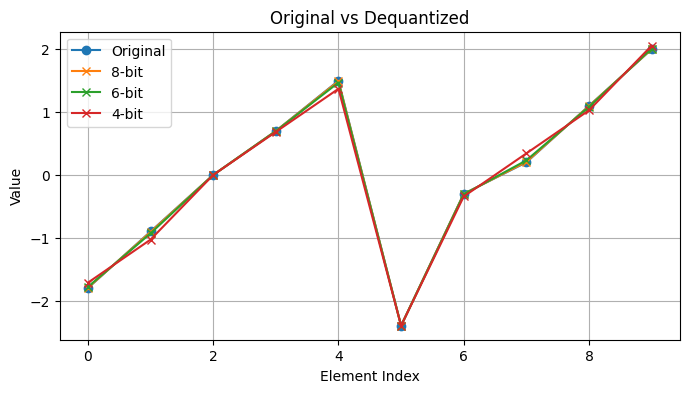

In [4]:
original=tensor.flatten()
x=np.arange(len(original))

plt.figure(figsize=(8,4))
plt.plot(x,original,marker='o',label='Original')

for bits in [8,6,4]:
    plt.plot(x,dequantized[bits].flatten(),marker='x',label=f'{bits}-bit')

plt.xlabel("Element Index")
plt.ylabel("Value")
plt.title("Original vs Dequantized")
plt.grid(True)
plt.legend()
plt.show()


## Visualization 2: MSE vs Bit Width

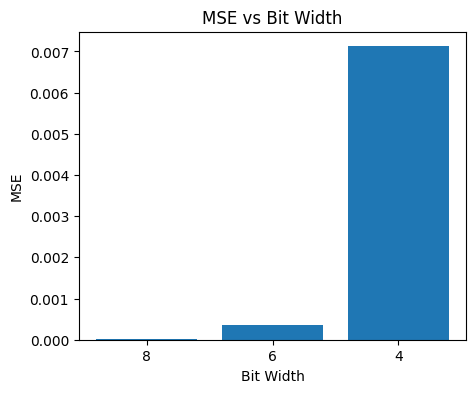

In [5]:
plt.figure(figsize=(5,4))
plt.bar(table["Bits"].astype(str),table["MSE"])
plt.xlabel("Bit Width")
plt.ylabel("MSE")
plt.title("MSE vs Bit Width")
plt.show()


## Visualization 3: Maximum Error vs Bit Width

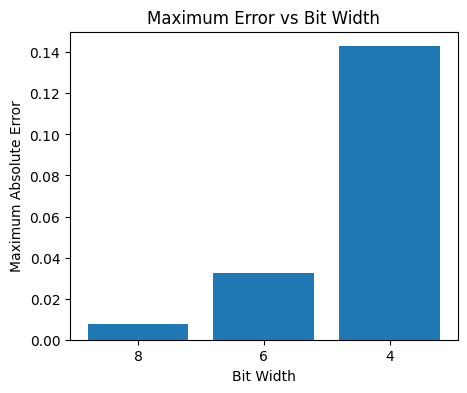

In [6]:
plt.figure(figsize=(5,4))
plt.bar(table["Bits"].astype(str),table["Max Error"])
plt.xlabel("Bit Width")
plt.ylabel("Maximum Absolute Error")
plt.title("Maximum Error vs Bit Width")
plt.show()


# Observations

- **8-bit quantization** provides the highest precision and the lowest quantization error.
- **6-bit quantization** has moderate error while using fewer representable levels.
- **4-bit quantization** has the largest quantization error because only 15 levels are available.
- As the number of bits decreases, the scale becomes larger and the reconstructed values deviate more from the original tensor.
- Lower bit widths reduce memory usage and computation cost but increase information loss.
